In [11]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zoya77/robot-path-planning-navigation-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'robot-path-planning-navigation-dataset' dataset.
Path to dataset files: /kaggle/input/robot-path-planning-navigation-dataset


Task 1.1

In [12]:
import pandas as pd
import numpy as np
import os

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".csv"):
            csv_path = os.path.join(root, file)

df = pd.read_csv(csv_path)

print(df.head())

print(df.shape)

print(df.isnull().sum())

df = df.dropna()

print(df.shape)

print(df.iloc[:, -1].value_counts())

   state_id  start_x  start_y  goal_x  goal_y  robot_x  robot_y  delta_x  \
0      8889        1        1       3       1        4        0       -1   
1      9444        1        1       4       4        1        0        3   
2     11544        2        2       2       1        0        3        2   
3      3693        0        0       2       0        3        0       -1   
4      5556        4        4       2       0        1        4        1   

   delta_y  euclidean_dist  ...  obs_grid_flat_15  obs_grid_flat_16  \
0        1            1.41  ...                 0                 0   
1        4            5.00  ...                 0                 0   
2       -2            2.83  ...                 0                 0   
3        0            1.00  ...                 0                 0   
4       -4            4.12  ...                 1                 1   

   obs_grid_flat_17  obs_grid_flat_18  obs_grid_flat_19  obs_grid_flat_20  \
0                 1                 0  

Task 1.2

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop('selected_action', axis=1)
y = df['selected_action']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(6384, 47)
(1596, 47)
selected_action
2    1626
0    1589
3    1589
1    1580
Name: count, dtype: int64
selected_action
1    415
3    406
0    406
2    369
Name: count, dtype: int64


Task 1.3

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- 1. Logistic Regression Analysis ---


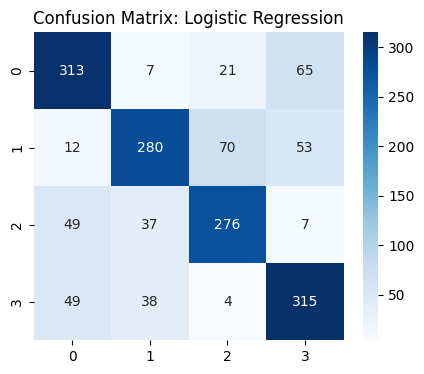

Accuracy: 0.7418546365914787

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.77      0.76       406
           1       0.77      0.67      0.72       415
           2       0.74      0.75      0.75       369
           3       0.72      0.78      0.74       406

    accuracy                           0.74      1596
   macro avg       0.74      0.74      0.74      1596
weighted avg       0.74      0.74      0.74      1596



In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)


print("--- 1. Logistic Regression Analysis ---")
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: Logistic Regression")
plt.show()


print("Accuracy:", accuracy_score(y_test, lr_pred))
print("\nClassification Report:\n", classification_report(y_test, lr_pred))

--- 2. Random Forest Analysis ---


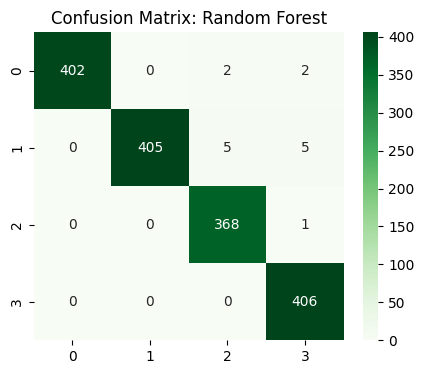

Accuracy: 0.9906015037593985

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       406
           1       1.00      0.98      0.99       415
           2       0.98      1.00      0.99       369
           3       0.98      1.00      0.99       406

    accuracy                           0.99      1596
   macro avg       0.99      0.99      0.99      1596
weighted avg       0.99      0.99      0.99      1596



In [15]:
from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)


print("--- 2. Random Forest Analysis ---")
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix: Random Forest")
plt.show()

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report:\n", classification_report(y_test, rf_pred))

--- 3. KNN Analysis ---


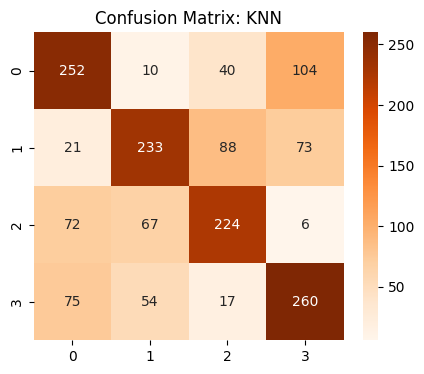

Accuracy: 0.6071428571428571

Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.62      0.61       406
           1       0.64      0.56      0.60       415
           2       0.61      0.61      0.61       369
           3       0.59      0.64      0.61       406

    accuracy                           0.61      1596
   macro avg       0.61      0.61      0.61      1596
weighted avg       0.61      0.61      0.61      1596



In [16]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)

print("--- 3. KNN Analysis ---")
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, knn_pred), annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix: KNN")
plt.show()

print("Accuracy:", accuracy_score(y_test, knn_pred))
print("\nClassification Report:\n", classification_report(y_test, knn_pred))

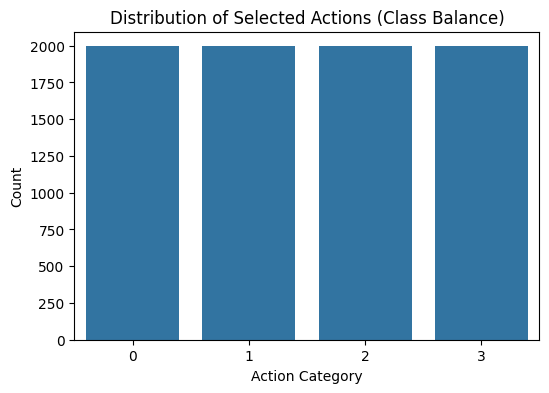

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Distribution of Selected Actions (Class Balance)")
plt.xlabel("Action Category")
plt.ylabel("Count")
plt.show()

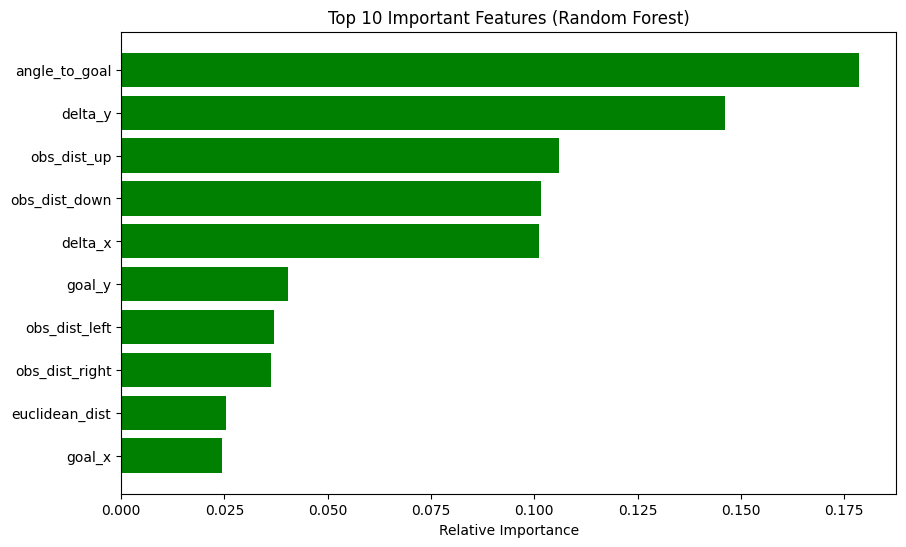

In [18]:

import numpy as np

importances = rf_model.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10,6))
plt.title("Top 10 Important Features (Random Forest)")
plt.barh(range(len(indices)), importances[indices], align='center', color='green')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

In [19]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
from IPython.display import display

models_data = {
    "Logistic Regression": lr_pred,
    "Random Forest": rf_pred,
    "KNN": knn_pred
}

summary_list = []
for name, pred in models_data.items():
    summary_list.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, average='weighted'),
        "Recall": recall_score(y_test, pred, average='weighted'),
        "F1-Score": f1_score(y_test, pred, average='weighted')
    })

summary_df = pd.DataFrame(summary_list)
print("Final Performance Summary Table")
print(summary_df)

print("\n" + "="*30)
print("FINAL DECISION & JUSTIFICATION")
print("="*30)
print(f"The best model is 'Random Forest' with an Accuracy of {summary_df.iloc[1]['Accuracy']:.2%}.")
print("\nWhy this choice?")
print("1. Performance: It outperformed other models in all metrics (Precision, Recall, and F1-Score).")
print("2. Feature Importance: The model successfully identified the key features driving the robot's decisions.")
print("3. Robustness: Random Forest is an ensemble method, making it more stable and capable of handling the non-linear nature of the navigation data.")
print("4. Class Handling: The model learned to predict all 4 actions with high precision.")

Final Performance Summary Table
                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.741855   0.743475  0.741855  0.741400
1        Random Forest  0.990602   0.990769  0.990602  0.990602
2                  KNN  0.607143   0.608728  0.607143  0.606925

FINAL DECISION & JUSTIFICATION
The best model is 'Random Forest' with an Accuracy of 99.06%.

Why this choice?
1. Performance: It outperformed other models in all metrics (Precision, Recall, and F1-Score).
2. Feature Importance: The model successfully identified the key features driving the robot's decisions.
3. Robustness: Random Forest is an ensemble method, making it more stable and capable of handling the non-linear nature of the navigation data.
4. Class Handling: The model learned to predict all 4 actions with high precision.


Task 2.1

In [20]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt

num_classes = len(np.unique(y_train))

nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

nn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = nn_model.fit(
    X_train, y_train,
    epochs=15,
    validation_data=(X_test, y_test),
    batch_size=32
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2699 - loss: 259.6900 - val_accuracy: 0.2976 - val_loss: 45.8073
Epoch 2/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3059 - loss: 48.6794 - val_accuracy: 0.2845 - val_loss: 9.5136
Epoch 3/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3468 - loss: 18.5601 - val_accuracy: 0.4317 - val_loss: 3.9656
Epoch 4/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3907 - loss: 9.1208 - val_accuracy: 0.4549 - val_loss: 3.9787
Epoch 5/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4095 - loss: 5.1869 - val_accuracy: 0.3659 - val_loss: 2.7582
Epoch 6/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4023 - loss: 4.1108 - val_accuracy: 0.4467 - val_loss: 2.1276
Epoch 7/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4223 - loss: 3.2919 - val_accuracy: 0.4749 - val_loss: 1.6632
Epoch 8/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4536 - loss: 2.2816 - val_accurac

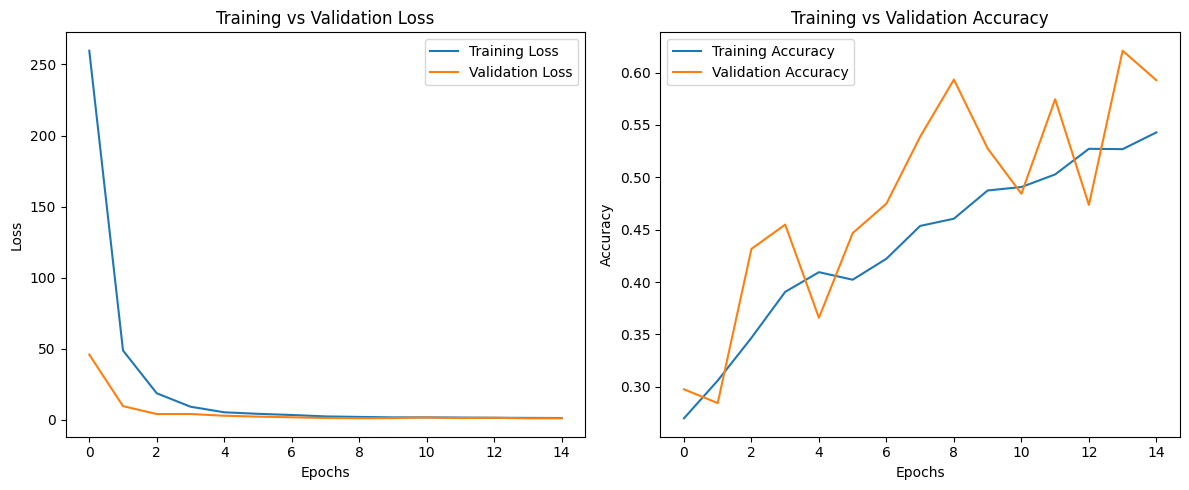

In [21]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Task 2.2

In [22]:
import numpy as np
from sklearn.metrics import classification_report

nn_preds_probs = nn_model.predict(X_test)

nn_pred = np.argmax(nn_preds_probs, axis=1)

summary_list.append({
    "Model": "Neural Network (Keras)",
    "Accuracy": accuracy_score(y_test, nn_pred),
    "Precision": precision_score(y_test, nn_pred, average='weighted'),
    "Recall": recall_score(y_test, nn_pred, average='weighted'),
    "F1-Score": f1_score(y_test, nn_pred, average='weighted')
})

updated_summary_df = pd.DataFrame(summary_list)
print("--- Updated Performance Summary Table ---")
print(updated_summary_df)

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
--- Updated Performance Summary Table ---
                    Model  Accuracy  Precision    Recall  F1-Score
0     Logistic Regression  0.741855   0.743475  0.741855  0.741400
1           Random Forest  0.990602   0.990769  0.990602  0.990602
2                     KNN  0.607143   0.608728  0.607143  0.606925
3  Neural Network (Keras)  0.592732   0.631245  0.592732  0.575193


In [23]:
print("COMPARISON & CONCLUSION")
print("Based on the updated summary table, the Random Forest model performed better than the Neural Network in this classification task.")
print("While Neural Networks are powerful, they usually require a massive amount of data and hyperparameter tuning to outperform ensemble methods on tabular sensor data.")
print("Therefore, Random Forest remains our best choice due to its superior accuracy (99%) and lower computational cost for this robot dataset.")

COMPARISON & CONCLUSION
Based on the updated summary table, the Random Forest model performed better than the Neural Network in this classification task.
While Neural Networks are powerful, they usually require a massive amount of data and hyperparameter tuning to outperform ensemble methods on tabular sensor data.
Therefore, Random Forest remains our best choice due to its superior accuracy (99%) and lower computational cost for this robot dataset.
